# 13_03.Convolution Neural Network(합성곱신경망)
- https://www.tensorflow.org/tutorials/images/cnn?hl=ko

## 1.기본 package 설정

In [ ]:
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기

import tensorflow as tf
from tensorflow import keras
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.12.0


## 2.데이터 불러오기

### 2.1 데이터 불러오기

In [ ]:
(X_train, y_train),(X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


### 2.2 자료구조 살펴보기

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)

ax = ax.flatten()

for i in range(10):
    img = X_train[y_train == i][0].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)

ax = ax.flatten()

for i in range(25):
    img = X_train[y_train == 7][i].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
X_train[y_train == 0][0]

In [ ]:
print(X_train.shape, X_train.dtype)
print(X_test.shape, X_test.dtype)

## 3.신경망

### 3.1 신경망 구성


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3),               # 필터개수, 필터크기(5,5)
                           padding = 'same',         # same 패딩 (default = valid)
                           strides = 2,              # strides(이동간격, default = 1)
                           activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),                      # flatten (차원을 모두 펼침)
    tf.keras.layers.Dense(256, activation='relu'),  # flatten 숫자와 동일하게 맞추어야 함
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 7, 7, 32)         0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 5, 5, 64)          18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 2, 2, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 256)               6

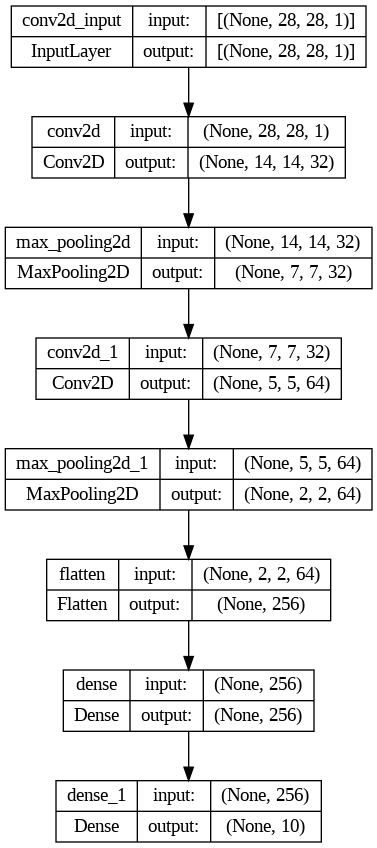

In [ ]:
tf.keras.utils.plot_model(model,
                          show_shapes = True,
                          to_file='model.png')

### 3.2 신경망 훈련
- 이진 분류 : binary_crossentropy
- 다중 분류 : sparse_categorical_crossentropy

In [ ]:
!pip install pyyaml h5py  # Required to save models in HDF5 format

In [ ]:
import os
checkpoint_path = "training_1/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

callback_list = [tf.keras.callbacks.ModelCheckpoint(filepath = checkpoint_path,
                                                    save_best_only = True,
                                                    verbose = 1),
               tf.keras.callbacks.EarlyStopping(patience = 5)]

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
np.random.seed(1)

history = model.fit(X_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1, # 검증용 데이터 10% 추출해서 훈련시 검정
                    callbacks = callback_list)

Epoch 1/10
844/844 [==============================] - ETA: 0s - loss: 0.4240 - accuracy: 0.9101
Epoch 1: val_loss improved from inf to 0.11863, saving model to training_1/cp.ckpt


844/844 [==============================] - 23s 8ms/step - loss: 0.4240 - accuracy: 0.9101 - val_loss: 0.1186 - val_accuracy: 0.9673
Epoch 2/10
833/844 [============================>.] - ETA: 0s - loss: 0.1032 - accuracy: 0.9688
Epoch 2: val_loss improved from 0.11863 to 0.08018, saving model to training_1/cp.ckpt


844/844 [==============================] - 5s 5ms/step - loss: 0.1025 - accuracy: 0.9690 - val_loss: 0.0802 - val_accuracy: 0.9778
Epoch 3/10
840/844 [============================>.] - ETA: 0s - loss: 0.0724 - accuracy: 0.9778
Epoch 3: val_loss did not improve from 0.08018
844/844 [==============================] - 4s 5ms/step - loss: 0.0726 - accuracy: 0.9777 - val_loss: 0.0967 - val_accuracy: 0.9710
Epoch 4/10
838/844 [============================>.] - ETA: 0s - loss: 0.0580 - accuracy: 0.9811
Epoch 4: val_loss did not improve from 0.08018
844/844 [==============================] - 4s 5ms/step - loss: 0.0580 - accuracy: 0.9810 - val_loss: 0.0861 - val_accuracy: 0.9740
Epoch 5/10
833/844 [============================>.] - ETA: 0s - loss: 0.0515 - accuracy: 0.9840
Epoch 5: val_loss improved from 0.08018 to 0.07310, saving model to training_1/cp.ckpt


844/844 [==============================] - 5s 5ms/step - loss: 0.0516 - accuracy: 0.9839 - val_loss: 0.0731 - val_accuracy: 0.9802
Epoch 6/10
838/844 [============================>.] - ETA: 0s - loss: 0.0432 - accuracy: 0.9864
Epoch 6: val_loss improved from 0.07310 to 0.06868, saving model to training_1/cp.ckpt


844/844 [==============================] - 5s 6ms/step - loss: 0.0433 - accuracy: 0.9864 - val_loss: 0.0687 - val_accuracy: 0.9820
Epoch 7/10
837/844 [============================>.] - ETA: 0s - loss: 0.0409 - accuracy: 0.9873
Epoch 7: val_loss did not improve from 0.06868
844/844 [==============================] - 4s 4ms/step - loss: 0.0408 - accuracy: 0.9873 - val_loss: 0.0780 - val_accuracy: 0.9837
Epoch 8/10
836/844 [============================>.] - ETA: 0s - loss: 0.0360 - accuracy: 0.9884
Epoch 8: val_loss improved from 0.06868 to 0.05830, saving model to training_1/cp.ckpt


844/844 [==============================] - 5s 5ms/step - loss: 0.0365 - accuracy: 0.9883 - val_loss: 0.0583 - val_accuracy: 0.9857
Epoch 9/10
842/844 [============================>.] - ETA: 0s - loss: 0.0309 - accuracy: 0.9899
Epoch 9: val_loss did not improve from 0.05830
844/844 [==============================] - 4s 5ms/step - loss: 0.0310 - accuracy: 0.9899 - val_loss: 0.0673 - val_accuracy: 0.9848
Epoch 10/10
835/844 [============================>.] - ETA: 0s - loss: 0.0262 - accuracy: 0.9918
Epoch 10: val_loss did not improve from 0.05830
844/844 [==============================] - 4s 4ms/step - loss: 0.0263 - accuracy: 0.9918 - val_loss: 0.0800 - val_accuracy: 0.9823


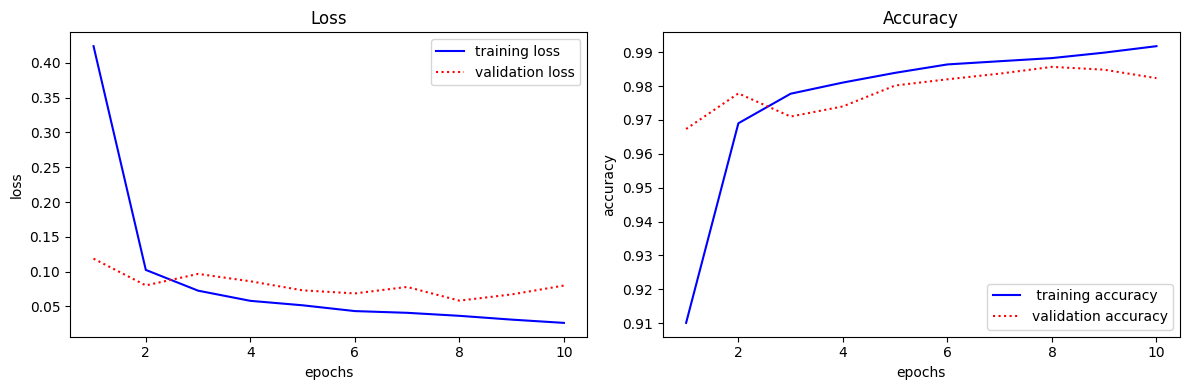

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss)+1)


plt.figure(figsize=(12, 4))

# 비용함수
plt.subplot(1, 2, 1)
plt.title("Loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(epochs, loss, 'b-', label='training loss')
plt.plot(epochs, val_loss, 'r:', label='validation loss')
plt.legend()

# 정확도
plt.subplot(1, 2, 2)
plt.title("Accuracy")
plt.ylabel("accuracy")
plt.xlabel('epochs')
plt.plot(epochs, accuracy, 'b-', label=" training accuracy")
plt.plot(epochs, val_accuracy, 'r:', label="validation accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 4.모델검정


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('test 비용: %.4f%%' % (100 * test_loss))
print('test 정확도: %.4f%%' % (100 * test_acc))

313/313 [==============================] - 1s 3ms/step - loss: 0.0706 - accuracy: 0.9815
test 비용: 7.0562%
test 정확도: 98.1500%


In [ ]:
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('best 모델, test 비용: %.4f%%' % (100 * test_loss))
print('best 모델, test 정확도: %.4f%%' % (100 * test_acc))

313/313 - 1s - loss: 0.0706 - accuracy: 0.9815 - 674ms/epoch - 2ms/step
best 모델, test 비용: 7.0562%
best 모델, test 정확도: 98.1500%


## 5.모델 및 커널 확인

### 5.1 테스트 결과확인

In [ ]:
np.argmax(model.predict(X_test[:10]), axis = 1)

1/1 [==============================] - 0s 164ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [ ]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

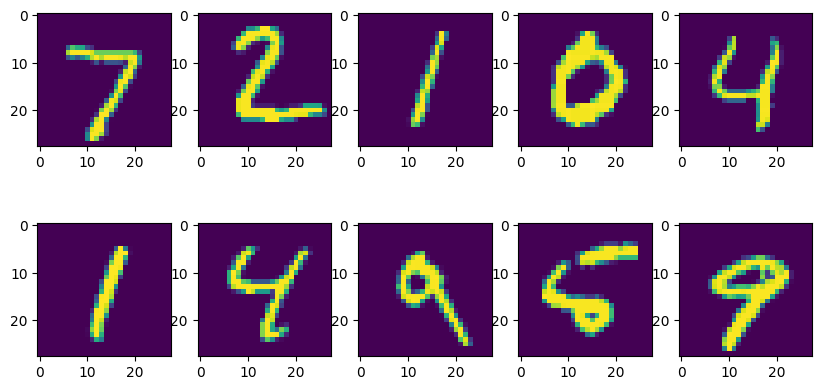

In [ ]:
fig = plt.figure(figsize = (10,5))
for i in range(10):
    fig.add_subplot(2,5, i+1)
    plt.imshow(X_test[i].reshape(28,28))

### 5.2 필터확인

In [ ]:
first_layer = model.layers[0]

In [ ]:
print(model.input)

KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='conv2d_input'), name='conv2d_input', description="created by layer 'conv2d_input'")


In [ ]:
from keras import models
first_activation = models.Model(inputs = model.input,
                                outputs = first_layer.output)
activation = first_activation(X_test[:10])

In [ ]:
print(activation.shape)
# (차원(10개 데이터), 높이, 넓이, 필터수)

(10, 14, 14, 32)


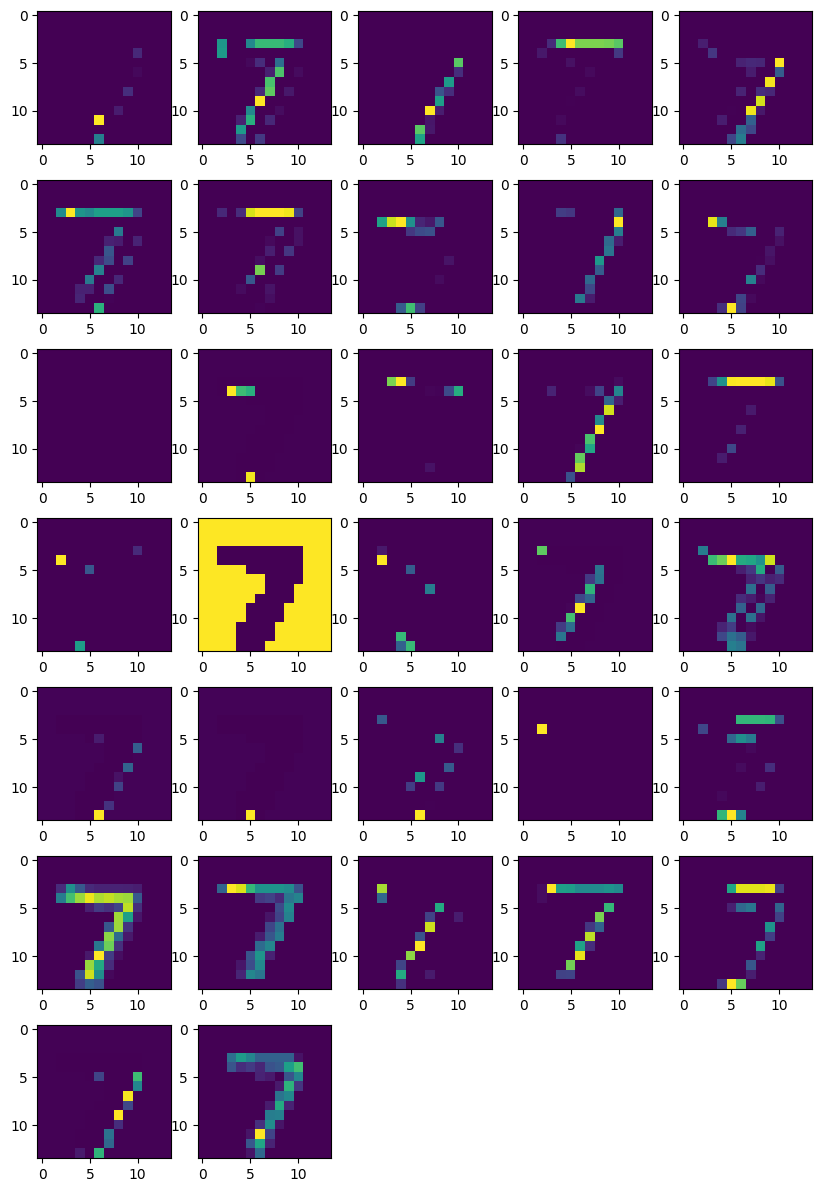

In [ ]:
fig = plt.figure(figsize = (10,15))
for i in range(32):                    # 필터 32개 출력
    fig.add_subplot(7, 5, i+1)
    plt.imshow(activation[0, :, :, i]) # 0번째(7번) 특성맵

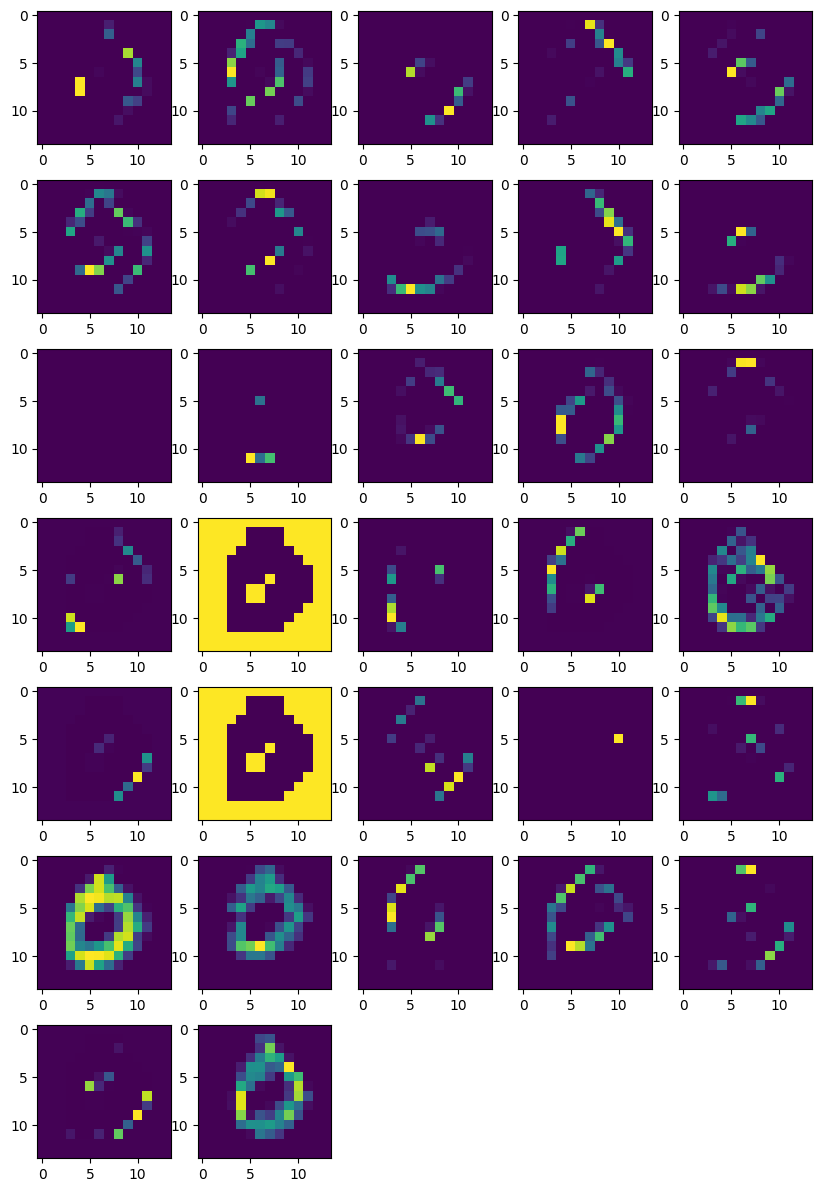

In [ ]:
fig = plt.figure(figsize = (10,15))
for i in range(32):                    # 필터 32개 출력
    fig.add_subplot(7, 5, i+1)
    plt.imshow(activation[3, :, :, i]) # 3번째(0번) 특성맵

### 5.3 커널확인

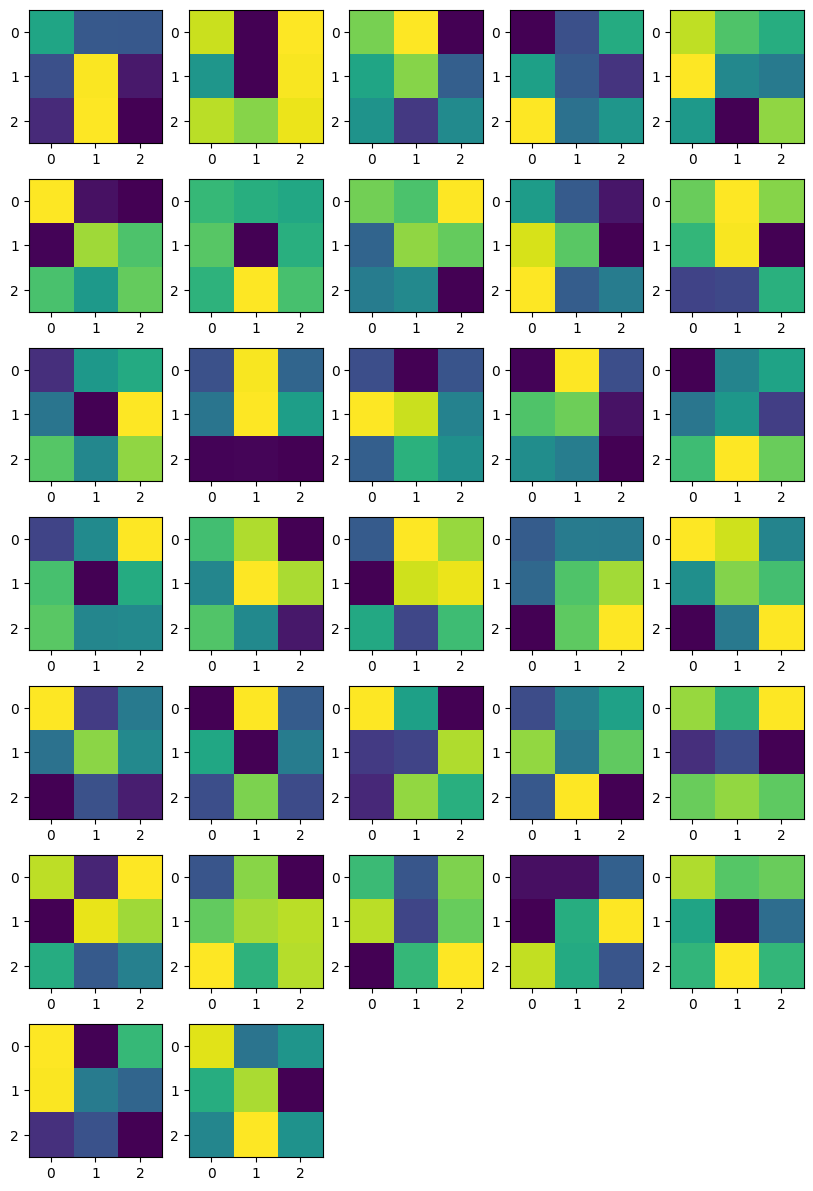

In [ ]:
fig = plt.figure(figsize = (10,15))
for i in range(32):                    # 필터 32개 출력
    fig.add_subplot(7, 5, i+1)
    plt.imshow(first_layer.kernel[:, :, 0, i]) # 높이, 넓이, 입력채널(흑백이므로 1개 = 0), 출력채널

## 6.모델 저장하기
- 모델 저장해서 활용하기

In [ ]:
model.save('cnn_model.h5')

In [ ]:
new_model = tf.keras.models.load_model('cnn_model.h5')

new_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 7, 7, 32)         0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 5, 5, 64)          18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 2, 2, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 256)               6